# ✈️ Flight Price Prediction 💰

Ever wondered **how much your flight will cost** before booking? 🤔  
This project predicts flight ticket prices using machine learning and historical flight data from Kaggle 📊. By analyzing factors like **airline ✈️, route 🌍, departure & arrival times ⏰, flight duration ⏳, and number of stops 🛑**, we can estimate the price of a ticket 💵.

Whether you’re a **traveler looking for the best deal 💸** or a **data enthusiast exploring predictive modeling 📈**, this project gives you insights into flight pricing trends and helps make **smarter booking decisions**.


### 🧠 Key Questions 

- Which airline has the highest average price?
- Are night flights cheaper?
- Does longer duration increase price?
- How does price change as days_left decreases?
- Is it cheaper to book early?
- How fast does price increase when departure date approaches?

### 📥 Loading the Dataset and Libraries

Before we start predicting flight prices, we need to install the necessary Python libraries and **load the dataset**.


In [40]:
# Install the required libraries
%pip install pandas numpy matplotlib seaborn scikit-learn -q 
# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Importing the library for data manipulation in tables
import pandas as pd 

# Importing the NumPy library for mathematical operations and arrays
import numpy as np  

# Importing the Matplotlib library for generating plots
import matplotlib.pyplot as plt  

# Importing the Seaborn library for statistical data visualization
import seaborn as sns  

from sklearn.linear_model import LinearRegression

# Jupyter Notebook magic command to display plots directly in the notebook
%matplotlib inline

In [42]:
# Load the watermark extension
%reload_ext watermark

# Display metadata for your notebook
%watermark -a "Maykon Analysis - Flight Price Prediction" -d -u -v -p numpy,pandas,matplotlib,seaborn

Author: Maykon Analysis - Flight Price Prediction

Last updated: 2026-02-24

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.9.0

numpy     : 2.4.1
pandas    : 3.0.0
matplotlib: 3.10.8
seaborn   : 0.13.2



In [43]:
# Load the Flight Price dataset from a local CSV file into a pandas DataFrame
data = r"data\flightprice.csv"

df = pd.read_csv(data)

In [44]:
df.head() #Displays the first rows of the DataFrame df. 

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [45]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


### 📊 Exploratory Data Analysis (EDA)
I will now begin the exploratory data analysis to better understand the dataset. In this step, I will examine the structure of the data, analyze statistical summaries, identify missing values, and explore relationships between the features and the flight price. This will help uncover patterns and insights to guide the regression modeling process.

In [46]:
df.describe(include='number') # Generates summary statistics for all numerical columns in the DataFrame.

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [47]:
df.describe(include='str') # Generates summary statistics only for string (text) columns in the DataFrame.

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [48]:
df.describe(include='all') #Generates a complete statistical summary of the DataFrame.

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153.000000,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,NaN,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,NaN,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,NaN,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,86646.852011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,75038.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,225114.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [49]:
df.info() #Displays a summary of the DataFrame structure. 

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [50]:
df.shape # (rows, columns)

(300153, 12)

In [51]:
df.sample(5) # Random 5 rows

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
57167,57167,Indigo,6E-711,Mumbai,Afternoon,one,Night,Bangalore,Economy,6.00,26,3956
212759,212759,Air_India,AI-560,Delhi,Morning,one,Afternoon,Bangalore,Business,6.17,12,35490
260398,260398,Vistara,UK-854,Bangalore,Evening,one,Morning,Chennai,Business,14.42,33,44280
204104,204104,AirAsia,I5-1531,Chennai,Night,one,Morning,Hyderabad,Economy,10.75,19,1550
243491,243491,Vistara,UK-940,Mumbai,Evening,one,Evening,Chennai,Business,20.58,29,72125


In [52]:
df.dtypes #Displays the data type of each column in the DataFrame.

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

In [53]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='str')

### 📊 Why Perform Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is an essential step before building a regression model.

We perform EDA to:

- 🔍 Understand the structure of the dataset  
- 📈 Analyze the distribution of variables  
- 🧹 Detect missing values and inconsistencies  
- 📊 Identify relationships between features and the target variable  
- 🚨 Detect outliers that may affect the model  
- 🎯 Select relevant features for modeling  

EDA helps uncover patterns, trends, and potential issues in the data.

**In short:**  
EDA allows us to understand the data deeply before building and training a machine learning model.

### 🧹 Data Cleaning

After completing the exploratory data analysis, the next step is data cleaning.

In this stage, I will handle missing values, remove or treat outliers, correct data types if necessary, and ensure the dataset is consistent and ready for modeling.

Data cleaning is essential to improve data quality and ensure that the regression model produces accurate and reliable results.

In [54]:
df.isnull().sum() # Count missing values per column

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [55]:
# Example conversion
df['price_usd'] = df['price'] * 0.012  # converting INR to USD

In [56]:
# Drop useless columns
df.drop(columns=['Unnamed: 0', 'flight', 'price'], inplace=True)

In [57]:
df.duplicated().sum() # Count duplicates

np.int64(2213)

In [58]:
df.head(10) #Displays the first rows of the DataFrame df.

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,71.436
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,71.436
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,71.472
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,71.460
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,71.460
5,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,71.460
6,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,72.720
7,Vistara,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,72.720
8,GO_FIRST,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,71.448
9,GO_FIRST,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,71.448


In [59]:
dfc = df.copy() #It creates a new independent copy of the DataFrame.

In [60]:
dfc.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,71.436
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,71.436
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,71.472
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,71.460
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,71.460


In [61]:
dfc.describe(include='all')

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
count,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,250.675926
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,272.373208
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,13.260000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,57.396000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,89.100000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,510.252000


In [62]:
dfc.dtypes

airline                 str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price_usd           float64
dtype: object

In [63]:
dfc.sample(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
129912,GO_FIRST,Kolkata,Evening,one,Morning,Mumbai,Economy,16.25,17,111.756
158484,Indigo,Hyderabad,Morning,one,Afternoon,Delhi,Economy,5.33,49,40.764
33710,Air_India,Delhi,Early_Morning,one,Night,Hyderabad,Economy,14.42,38,68.100
285651,Air_India,Hyderabad,Night,one,Afternoon,Chennai,Business,15.83,8,764.292
16645,Air_India,Delhi,Morning,one,Night,Bangalore,Economy,11.58,33,89.736
182351,Vistara,Chennai,Morning,one,Night,Delhi,Economy,14.00,16,105.636
73904,Vistara,Mumbai,Night,one,Morning,Hyderabad,Economy,12.08,27,41.208
231678,Air_India,Mumbai,Evening,one,Afternoon,Bangalore,Business,18.50,21,655.296
76198,Vistara,Mumbai,Morning,zero,Afternoon,Hyderabad,Economy,1.50,42,41.400
277121,Air_India,Hyderabad,Early_Morning,one,Night,Delhi,Business,16.75,47,571.032


In [64]:
dfc.columns

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price_usd'],
      dtype='str')

#### 🧹 Data Cleaning Process (Summary)

_During the cleaning stage, I prepared the dataset for regression analysis by handling missing values, correcting data types, and removing redundant columns to avoid multicollinearity. I also prepared categorical variables for encoding, since regression models require numerical inputs._

#### 🔎 Before building regression models to predict flight prices
 I performed structured data analysis to better understand the dataset and identify the key factors influencing ticket prices. Since this is a regression problem with price as the target variable, the analysis focuses on answering the central question:

**Which factors most strongly affect flight price?**

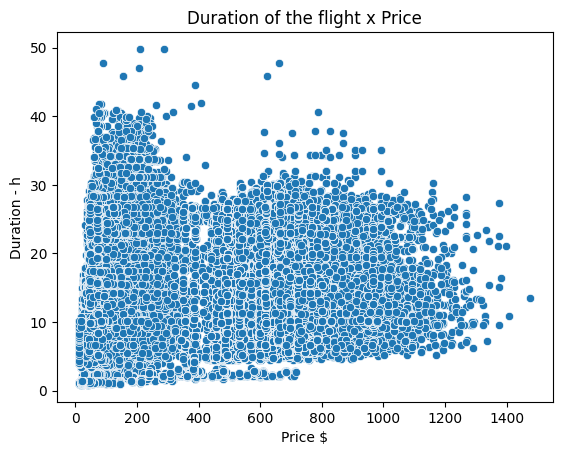

' This scatter plot shows the relationship between flight duration and ticket price. \nIt helps identify whether longer flights tend to be more expensive and whether a linear relationship exists between these variables. \nThe distribution of points also allows the detection of variability and possible outliers that could affect the regression model.'

In [65]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='price_usd', y='duration')
plt.xlabel('Price $')
plt.ylabel('Duration - h')
plt.show()

""" This scatter plot shows the relationship between flight duration and ticket price. 
It helps identify whether longer flights tend to be more expensive and whether a linear relationship exists between these variables. 
The distribution of points also allows the detection of variability and possible outliers that could affect the regression model."""

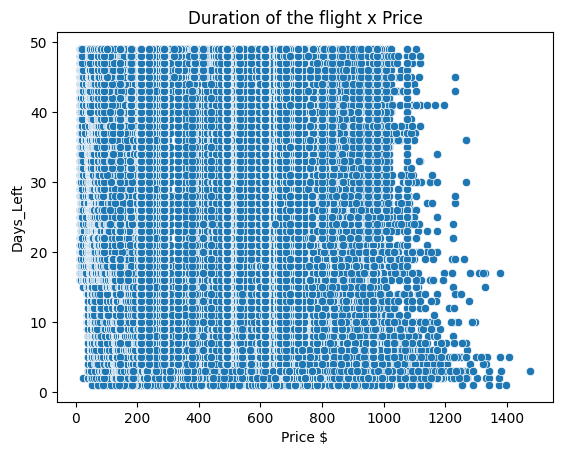

In [66]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='price_usd', y='days_left')
plt.xlabel('Price $')
plt.ylabel('Days_Left')
plt.show()

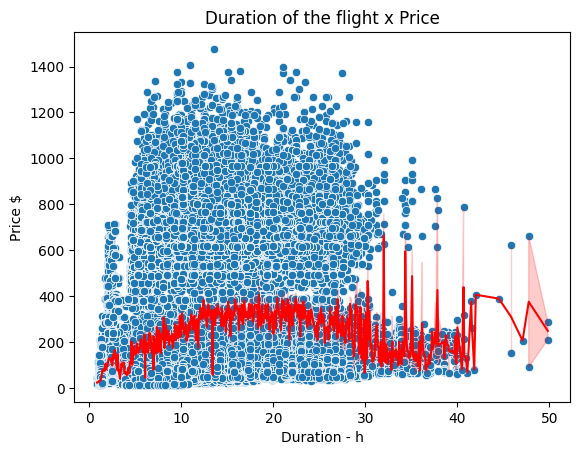

In [67]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='duration', y='price_usd')
sns.lineplot(data=dfc, x='duration', y='price_usd', color='red')
plt.xlabel('Duration - h')
plt.ylabel('Price $')
plt.show()

The plot shows that most flight prices are concentrated between approximately $20,000 and $40,000 across different durations. Although there are some peaks reaching $60,000 to $80,000, these values are not frequent and likely represent specific flights or outliers.

The red trend line suggests a mild positive relationship between duration and price for short to medium flights, but the pattern is not strongly linear. The high dispersion of points indicates that duration alone does not strongly determine ticket price, and other variables likely have significant influence in the regression model.

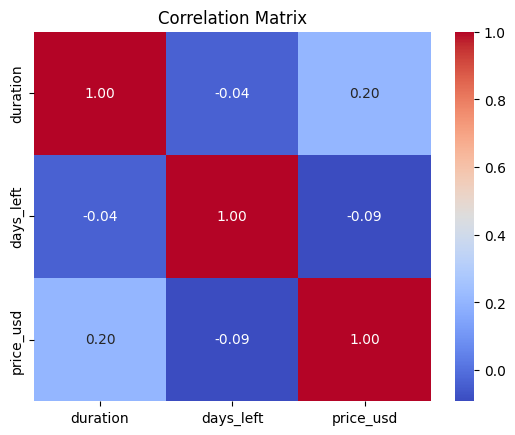

In [68]:
numeric_features = ['duration', 'days_left', 'price_usd']
corr_matrix = dfc[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- None of these variables show strong correlation with each other.

- "duration" and "price" have a slight positive relationship.

- The others are nearly independent in a linear sense.

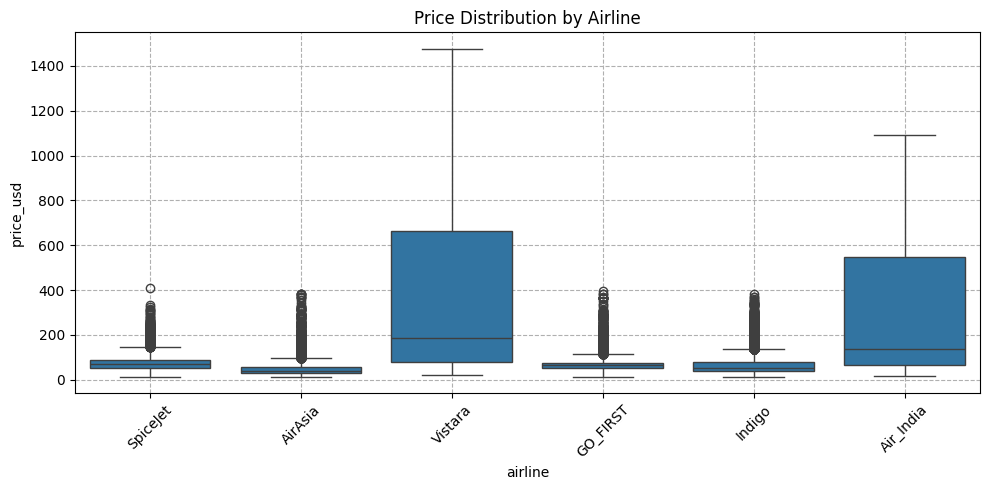

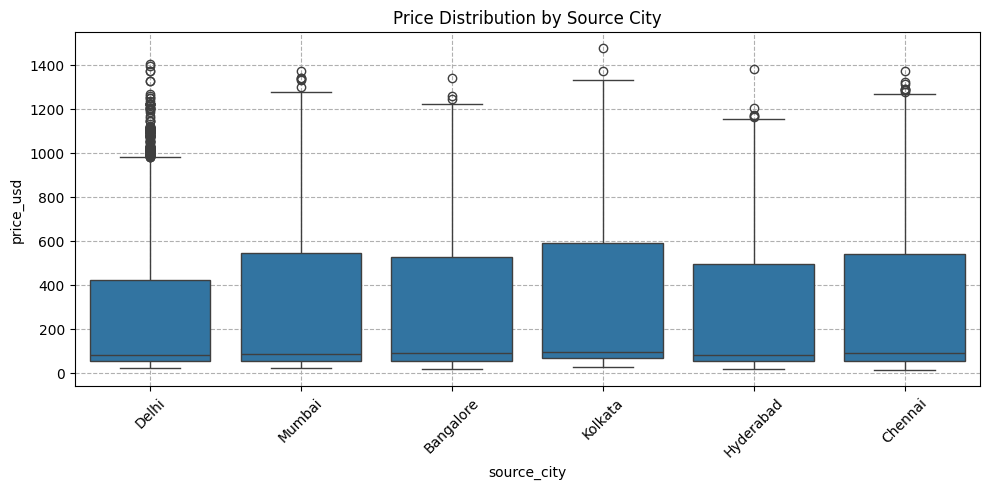

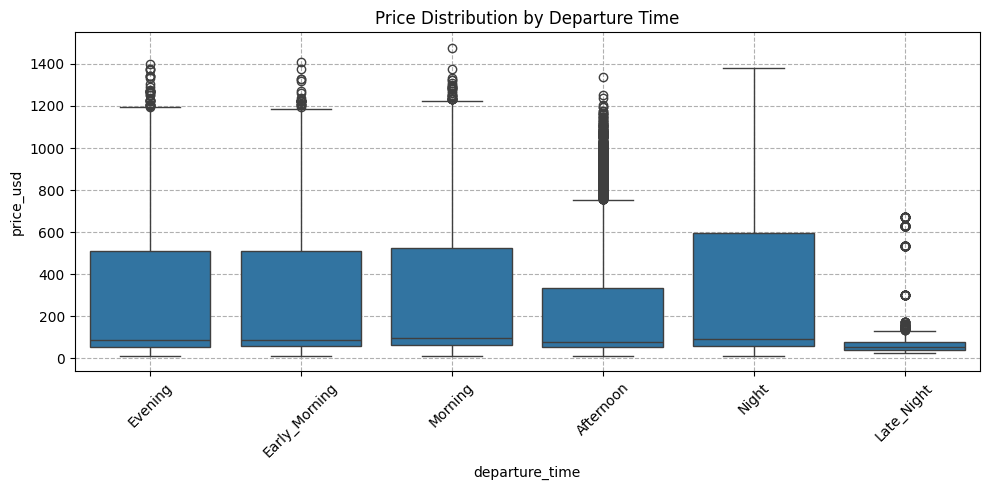

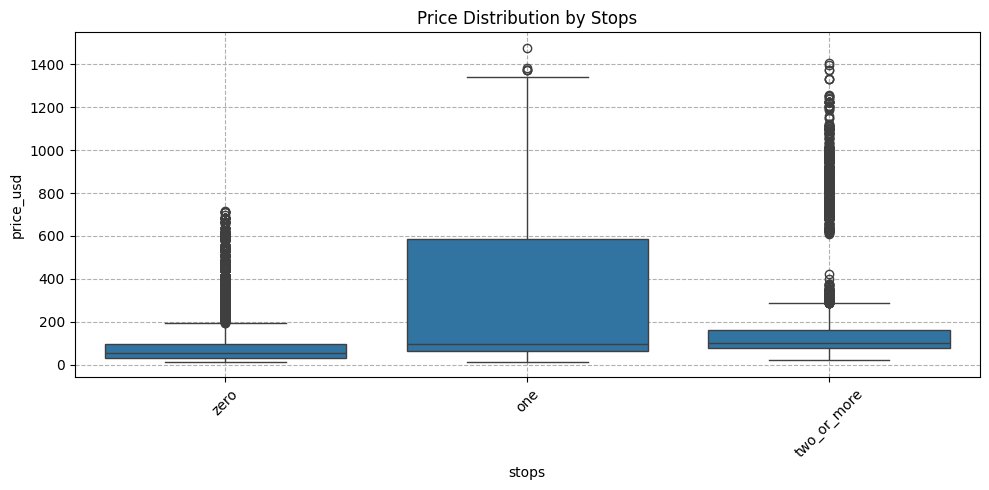

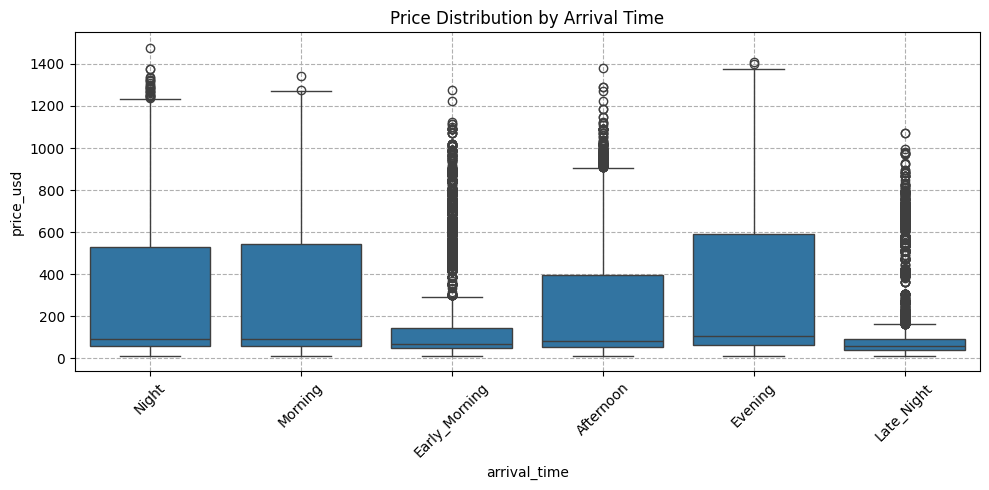

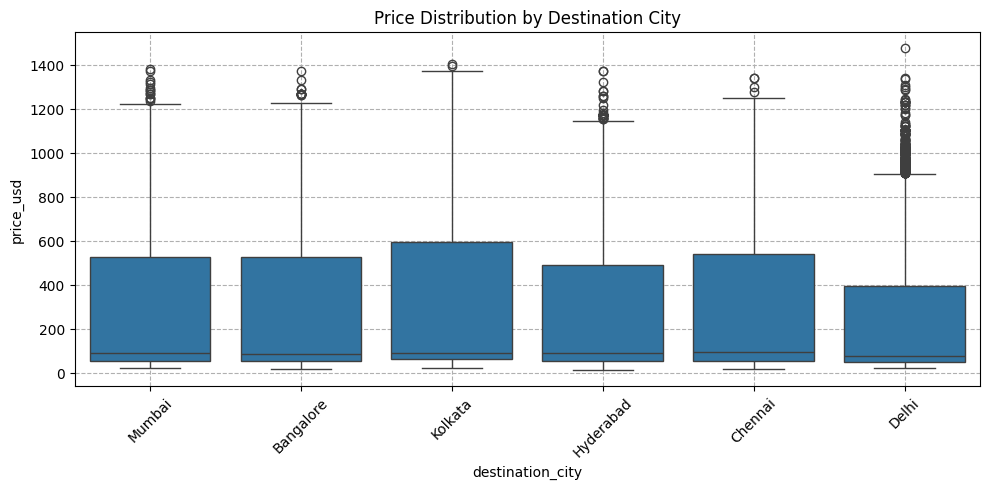

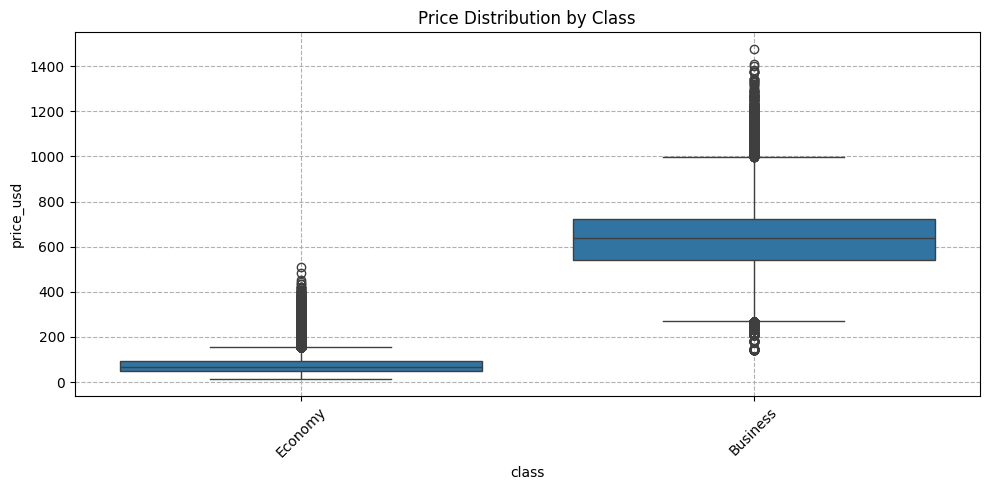

In [69]:
categorical_features = [
    'airline', 'source_city', 'departure_time',
    'stops', 'arrival_time', 'destination_city', 'class'
]

for col in categorical_features:
    plt.figure(figsize=(10,5))
    
    sns.boxplot(data=dfc, x=col, y='price_usd')
    
    plt.title(f'Price Distribution by {col.replace("_"," ").title()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, linestyle="--")
    
    plt.show()

**Airlines**

From this analysis, we can observe that SpiceJet, AirAsia, GO First, and Indigo tend to have the lowest prices on average, while Vistara and Air India are generally more expensive, based on their mean ticket prices.

**Source City**

The source city does not show strong differences in price distribution. Most cities have a median price around $100, while the third quartile (Q3) ranges approximately between $450 and $510, indicating relatively similar pricing patterns across departure cities.

**Departure Time**

The departure time shows only small variations in price. Most categories maintain a similar median price. However, afternoon and late-night departures tend to be slightly cheaper, with late-night flights showing the lowest prices overall.

**Number of Stops**

The number of stops clearly influences ticket prices. Flights with one stop can reach prices of around $600 at the third quartile, while the median price remains close to $100. This suggests that flights with additional stops may increase travel cost variability.

**Arrival Time**

The boxplot shows that flight prices are relatively similar across arrival time categories. Although evening flights show slightly higher variability and more expensive outliers, the median prices remain comparable. This suggests that arrival time is likely not a major factor influencing ticket prices.

**Destination City**

The destination city does not appear to strongly influence ticket prices. The median price remains relatively stable across cities. However, Hyderabad and Delhi show slightly lower third quartile values, indicating somewhat cheaper flights, while Delhi also presents some expensive outliers.

**Class**

The travel class has the strongest impact on ticket prices.
Business class tickets are significantly more expensive than economy class.

The median price for business class exceeds $600, with maximum values reaching over $1000, and some extreme outliers above $1400.

In contrast, economy class flights have a median price below $100, with the highest outliers remaining below $600.

This indicates that travel class is one of the most important factors affecting flight prices.

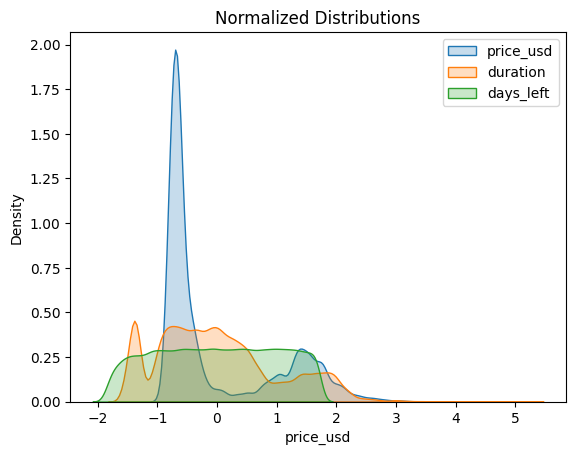

In [70]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = ['price_usd', 'duration', 'days_left']

scaler = StandardScaler()
scaled = scaler.fit_transform(dfc[features])

scaled_df = pd.DataFrame(scaled, columns=features)

for col in features:
    sns.kdeplot(scaled_df[col], fill=True, label=col)

plt.title('Normalized Distributions')
plt.legend()
plt.show()

The normalized distributions show that flight prices are highly right-skewed, indicating many low-cost flights and fewer expensive ones. Flight duration has a wider distribution, suggesting a variety of route lengths. The number of days left before departure appears more evenly distributed, indicating that bookings occur across a range of time periods.

### Regression Model for Flight Price Prediction

After exploring the dataset and analyzing the variables that influence ticket prices, the next step is to build a regression model to predict the price of airline tickets.

The goal of this model is to learn the relationship between several features—such as airline, departure time, number of stops, travel class, flight duration, and the number of days left before departure—and the final ticket price.

To accomplish this task, we use a supervised learning approach where the dataset is divided into **features (independent variables)** and a **target variable (dependent variable)**. The target variable is the ticket price (`price_usd`), while the remaining columns are used as input features for the model.

By training a regression model on this data, we aim to estimate how each feature contributes to the ticket price and generate predictions for new flight data.


In [71]:
X = dfc.drop(columns=['price_usd']) # X → contains all independent variables (airline, city, duration, days_left, etc.)
y = dfc['price_usd'] # y → contains the dependent variable (ticket price)

To train and evaluate the regression model, the dataset is divided into training and testing sets. The training set is used to teach the model the relationship between the features and the target variable, while the test set is used to evaluate how well the model performs on unseen data.

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

To train and evaluate the regression model, the dataset is divided into training and testing sets. The training set is used to teach the model the relationship between the features and the target variable, while the test set is used to evaluate how well the model performs on unseen data.

In [73]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure both datasets have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#dataset contains string columns, and regression models can only work with numerical values. So we need to convert them with get_bummies.

In [74]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


LinearRegression() → creates the regression model.

- model.fit(X_train, y_train) → trains the model using the training data.

- The model will learn the relationship between the features and the ticket price.

In [75]:
y_pred = model.predict(X_test)

- model.predict() → uses the trained model to predict ticket prices.

- X_test → the data the model has never seen before.

- y_pred → the predicted ticket prices.

#### Evaluate the Model

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 54.63945380138659
MSE: 6583.7908449106735
R2 Score: 0.9113048651706634
